In [5]:
from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting
import numpy as np
import matplotlib.pyplot as plt 
import torch
from kan import KAN


Epoch     0   Loss = 9.3164e+01
Epoch   500   Loss = 5.5689e+00
Epoch  1000   Loss = 1.0395e+00
Epoch  1500   Loss = 3.9285e-01
Epoch  2000   Loss = 2.3097e-01
Epoch  2500   Loss = 1.6387e-01
Epoch  3000   Loss = 1.2549e-01
Epoch  3500   Loss = 1.0867e-01
Epoch  4000   Loss = 1.0108e-01
Epoch  4500   Loss = 9.7967e-02
Epoch  5000   Loss = 9.6250e-02
Epoch  5500   Loss = 9.5239e-02
Epoch  6000   Loss = 9.4505e-02
Epoch  6500   Loss = 9.4002e-02
Epoch  7000   Loss = 9.3571e-02
Epoch  7500   Loss = 9.3198e-02
Epoch  8000   Loss = 9.3317e-02
Epoch  8500   Loss = 9.2793e-02
Epoch  9000   Loss = 9.2363e-02
Epoch  9500   Loss = 9.2061e-02

Relative L2 error = 3.259e-02


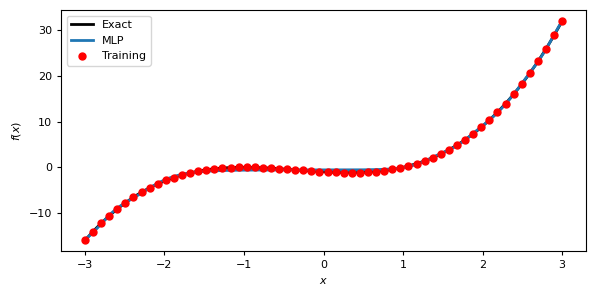

In [57]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# Reproducibility
# =====================================================
torch.manual_seed(1)
np.random.seed(1)

# =====================================================
# Target function
# =====================================================
def f(x):
    return x**3 + x**2 - x - 1

# =====================================================
# Training data
# =====================================================
n_train = 60

x_train = np.linspace(-3,3,n_train)
y_train = f(x_train)

# Test grid
x_test = np.linspace(-3,3,500)
y_exact = f(x_test)

# Convert to tensors
X_train = torch.tensor(x_train[:,None], dtype=torch.float32)
Y_train = torch.tensor(y_train[:,None], dtype=torch.float32)

X_test = torch.tensor(x_test[:,None], dtype=torch.float32)

# =====================================================
# MLP
# =====================================================
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(1,4),
            nn.Tanh(),

            nn.Linear(4,4),
            nn.Tanh(),

            nn.Linear(4,1)

        )

    def forward(self,x):
        return self.net(x)

model = MLP()

# =====================================================
# Optimizer
# =====================================================
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-2
)

# =====================================================
# Training
# =====================================================
epochs = 10_000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(X_train)

    loss = criterion(pred,Y_train)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}   Loss = {loss.item():.4e}")

# =====================================================
# Prediction
# =====================================================
model.eval()

with torch.no_grad():

    y_pred = model(X_test).numpy().flatten()

# =====================================================
# Relative L2 error
# =====================================================
rel_error = np.linalg.norm(y_pred-y_exact)/np.linalg.norm(y_exact)

print(f"\nRelative L2 error = {rel_error:.3e}")

# =====================================================
# Plot approximation
# =====================================================
plt.figure(figsize=(6,3))

plt.plot(
    x_test,
    y_exact,
    'k',
    lw=2,
    label='Exact'
)

plt.plot(
    x_test,
    y_pred,
    color='tab:blue',
    lw=2,
    label='MLP'
)

plt.scatter(
    x_train,
    y_train,
    color='red',
    s=25,
    zorder=5,
    label='Training'
)

plt.xlabel("$x$")
plt.ylabel("$f(x)$")

plt.legend()

plt.tight_layout()

plt.show()

 

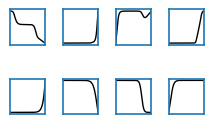

In [59]:
# =====================================================
# Plot the 8 hidden activations
# =====================================================
with torch.no_grad():

    x_plot = torch.tensor(x_test[:, None], dtype=torch.float32)

    # First hidden layer
    z1 = model.net[0](x_plot)          # Linear(1->4)
    a1 = model.net[1](z1)              # ReLU

    # Second hidden layer
    z2 = model.net[2](a1)              # Linear(4->4)
    a2 = model.net[3](z2)              # Tanh

# -----------------------------------------------------
# Plot
# -----------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(2.5, 1.5), sharex=True)

# First hidden layer
for i in range(4):
    ax = axes[0, i]
    ax.plot(x_test, a2[:, i].numpy(), lw=1, color='black')

    ax.set_xlim(-3, 3)

    # Square panels
    ax.set_box_aspect(1)

    # Remove grid
    ax.grid(False)

    # Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

# Second hidden layer
for i in range(4):
    ax = axes[1, i]
    ax.plot(x_test, a1[:, i].numpy(), lw=1, color='black')

    ax.set_xlim(-3, 3)

    # Square panels
    ax.set_box_aspect(1)

    # Remove grid
    ax.grid(False)

    # Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])


for ax in axes.ravel():

    ax.set_xlim(-3, 3)
    ax.set_box_aspect(1)

    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Blue frame
    for spine in ax.spines.values():
        spine.set_color("tab:blue")
        spine.set_linewidth(1.2)

    plt.subplots_adjust(
        wspace=0.5,   # horizontal space
        hspace=0.5    # vertical space
    )

plt.savefig("figures/mlp.svg", dpi=300, bbox_inches='tight') 
plt.show()